## Image Cleaning - Open CV for STL-10

The objective of this Python notebook is to compare 5 different Image Cleaning techniques on the TensorFlow STL-10 dataset, via OpenCV.

The methods used here are:
- No Processing
- MinMax Scaling
- StandardScaler
- QuantileTransformer
- PCA

In [1]:
!pip install tensorflow-datasets

In [2]:
import numpy as np
import pandas as pd
import cv2

import matplotlib.pyplot as plt

import tensorflow_datasets as tfds

In [3]:
def load_tfds_dataset(datasetName):
  ds_train, ds_test = tfds.load(
    datasetName,
    split=["train", "test"],
    as_supervised=True
  )
  X_train = np.array([x.numpy() for x, y in ds_train])
  y_train = np.array([y.numpy() for x, y in ds_train])
  X_test = np.array([x.numpy() for x, y in ds_test])
  y_test = np.array([y.numpy() for x, y in ds_test])

  return X_train, y_train, X_test, y_test

trainImg, trainLabel, testImg, testLabel = load_tfds_dataset("stl10")

print(trainLabel.shape, testLabel.shape)

(5000,) (8000,)


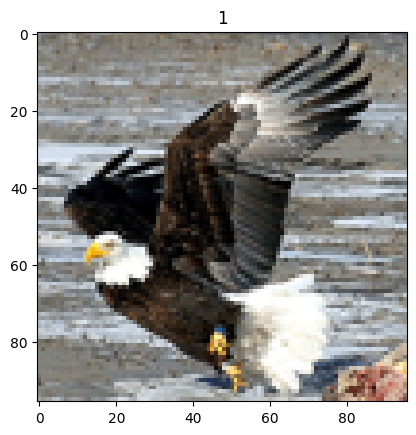

In [4]:
image = trainImg[0]
label = trainLabel[0]

plt.imshow(image)
plt.title(label)
plt.show()

## Image Cleaning Methods

In [5]:
# Method 1 - No Cleaning

def noClean(img):
  if img.ndim == 3:  # RGB image
    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  return img

In [6]:
# Method 2 - MinMaxScaling

def minMaxScaling(img):
  if img.ndim == 3:  # RGB image
    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  img = img.astype(np.float32)
  featureRange = (0, 1)
  return cv2.normalize(img, None, alpha=featureRange[0], beta=featureRange[1], norm_type=cv2.NORM_MINMAX)

In [7]:
# Method 3 - Standard Scaling

def standardScaling(img):
  if img.ndim == 3:  # RGB image
    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

  imgTemp = img.astype(np.float32)
  mean = np.mean(imgTemp)
  std = np.std(imgTemp)

  return (imgTemp - mean) / std

In [8]:
# Method 4 - QuantileTransformer

def quantileTransforming(img):
  if img.ndim == 3:  # RGB image
    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

  imgTemp = img.astype(np.float32)
  imgFlat = imgTemp.flatten()
  sortedImg = np.sort(imgFlat)

  cdf = np.linspace(0, 1, len(sortedImg))

  transformedValues = np.interp(imgFlat, sortedImg, cdf)

  h, w = img.shape[:2]
  return transformedValues.reshape(h, w)

In [9]:
# Method 5 - PCA

def pcaMethod(img):
  if img.ndim == 3:  # RGB image
    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

  imgTemp = img.astype(np.float32)
  flatImg = imgTemp.reshape(-1, image.shape[-1])

  mean = np.mean(flatImg, axis=0)
  centeredData = flatImg - mean

  covarianceMatrix = np.cov(centeredData, rowvar=False)
  eigenValues, eigenVectors = np.linalg.eigh(covarianceMatrix)

  sortedIndices = np.argsort(eigenValues)[::-1]
  eigenVectorsSorted = eigenVectors[:, sortedIndices]

  eigenVectorsFinal = eigenVectorsSorted[:, :50]

  pcaProjection = np.dot(centeredData, eigenVectorsFinal)

  reconstructedData = np.dot(pcaProjection, eigenVectorsFinal.T) + mean
  # return reconstructedData.reshape(image.shape)
  h, w = img.shape[:2]
  return reconstructedData.reshape(h, w)

## Simple RNN Model

In [10]:
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense
from keras.optimizers import Adam

def initRNN():
    model = Sequential([SimpleRNN(128, input_shape=(96, 96)), Dense(10, activation="softmax")])
    model.compile(optimizer=Adam(), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

In [11]:
# Need to make labels Categorical for RNN
from keras.utils import to_categorical

trainLabelCategorical = to_categorical(trainLabel, 10)
testLabelCategorical = to_categorical(testLabel, 10)

In [12]:
def comparisonModels(cleaningMethod):
  # Apply cleaning method to each image in train/test set
  trainImg2 = np.array([cleaningMethod(img) for img in trainImg])
  testImg2 = np.array([cleaningMethod(img) for img in testImg])

  # Normalising and re-shaping the images
  trainImg2 = (trainImg2/255.0).reshape(-1, 96, 96)
  testImg2 = (testImg2/255.0).reshape(-1, 96, 96)

  # RNN Model
  model = initRNN()
  model.fit(trainImg2, trainLabelCategorical, epochs=5, batch_size=64)

  return model.evaluate(testImg2, testLabelCategorical)

## Evaluation

In [13]:
modelNoCleaning = comparisonModels(noClean)
modelMinMax = comparisonModels(minMaxScaling)
modelStandard = comparisonModels(standardScaling)
modelQuantile = comparisonModels(quantileTransforming)
modelPCA = comparisonModels(pcaMethod)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.1412 - loss: 2.2438
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.1740 - loss: 2.0927
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.1798 - loss: 2.0863
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.1730 - loss: 2.0826
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.1971 - loss: 2.0699
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.1794 - loss: 2.0735
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.1068 - loss: 2.3035
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.1159 - loss: 2.3025
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.1333 - loss: 2.2861
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.1596 - loss: 2.2802
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.1717 - loss: 2.2344
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.1706 - loss: 2.2050
Epoch 1/

In [14]:
listAllModels = [modelNoCleaning, modelMinMax, modelStandard, modelQuantile, modelPCA]
print(listAllModels)

[[2.0758025646209717, 0.17499999701976776], [2.2030465602874756, 0.17000000178813934], [2.127747058868408, 0.18987500667572021], [2.2817981243133545, 0.1315000057220459], [2.0973007678985596, 0.17100000381469727]]


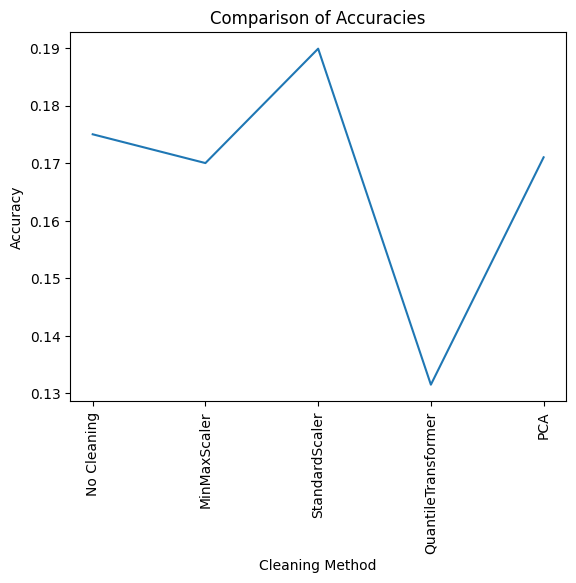

<Figure size 1200x1000 with 0 Axes>

In [15]:
plt.plot(["No Cleaning", "MinMaxScaler", "StandardScaler", "QuantileTransformer", "PCA"], [val[1] for val in listAllModels])
plt.title("Comparison of Accuracies")
plt.xlabel("Cleaning Method")
plt.xticks(rotation=90)
plt.ylabel("Accuracy")
plt.figure(figsize=(12, 10))
plt.show()

In the above graph:
- StandardScaler is the best performer in this case.
- Quantile Transform is by far the worst performer.
- MinMax, PCA, and no cleaning perform similarly.
- The overall accuracy of everything is generally pretty low, though.